<img src="/root/capsule/data/resources/swdb_logo.jpg">  

<h1 align="center">Workshop SWDB 2026 </h1> 
<h3 align="center">Monday, August 24, 2026</h3> 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>The Units Table</h2>

In extracellular electrophysiology, the primary data is the activity of individual **units** — putative neurons isolated from the raw voltage traces by spike sorting. In an NWB file, this information lives in the `units` table. This tutorial walks through how the `units` table is organized and how to work with spike times, quality control metrics, and waveforms. 

Learning objectives

- Load and navigate the `units` table from an NWB file (`pynwb`)
- Understand the main columns of the `units` table 
- Understand the quality metrics used to isolate good quality units 
- Work with spike times to compute and plot a firing rate
- Read a unit's mean waveform across the probe
</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Cell Type Lookup Table</h2>

The example data comes from recordings with **Neuropixels Opto** probes, a new device that combines high-density electrical recording with on-shank light emitters for optogenetic stimulation. In these sessions, light was used to **optotag** units — identify their cell type by testing whether they respond to light at short latency — in genetically defined populations such as striatal medium spiny neurons.

In this dataset, the `units` table contains standard columns plus a set of extra columns describing each unit's response to light. We'll focus on the standard columns first and touch briefly on the specialized columns. 

Reference: Lakunina et al. (2026), *Neuropixels Opto: combining high-resolution electrophysiology and optogenetics*, Nature Methods.

</div>

In [1]:
import pynwb
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
nwb_path = '/root/capsule/data/Neuropixels_Opto_ecephys_nwb_combined/ecephys_655565_2023-04-03_13-34-16_nwb/ecephys_655565_2023-04-03_13-34-16_experiment1_recording1.nwb'
nwb = pynwb.read_nwb(nwb_path)
nwb

Data type,float64
Shape,"(7800,)"
Array size,60.94 KiB
Data type,float64
Shape,"(7800,)"
Array size,60.94 KiB
Data type,float64
Shape,"(625262,)"
Array size,4.77 MiB
Data type,float64
Shape,"(625262,)"


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Loading the units table</h2>

The `units` table stores one row per isolated unit. Its columns fall into a few families that recur across ephys datasets:

- **Spike data** — the spike times for each unit, and derived quantities like the total spike count and mean firing rate.
- **Quality metrics** — numbers that summarize how well each unit was isolated during spike sorting (e.g. contamination, completeness, separation from other units).
- **Waveform features** — the mean spike waveform and scalar descriptions of its shape.

This particular dataset adds a further family of **optotagging columns** describing each unit's response to light, which we'll return to later. 

</div>

In [3]:
units = nwb.units[:]
units.head()

,spike_times,electrodes,waveform_mean,waveform_sd,unit_name,rp_contamination,shank,half_width,snr,l_ratio,...,internal_red_train_best_mean_jitter,internal_red_train_best_mean_reliability,internal_red_train_best_channel_diff,peak_channel,predicted_cell_type,ccf_ml,ccf_ap,ccf_dv,brain_id,brain_region
id,,,,,,,,,,,,,,,,,,,,,
0,"[422.0354600357091, 603.4513192151259, 696.160...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[1.4359092712402344, -3.377044916152954, 1.16...","[[29.977895736694336, 31.147375106811523, 24.1...",eed78c80-8afd-4e14-a368-563fbbd71de1,0.000000,,0.000157,7.488369,0.169544,...,NaN,0.000,99.0,1.0,untagged,2235.0,5917.0,4414.0,672,CP
1,"[959.883537661305, 1557.7273983430878, 1591.88...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[-1.3010398149490356, -0.4586401581764221, -2...","[[20.10042381286621, 23.633487701416016, 22.21...",4110a923-7f24-4d6d-932e-c98b6ed51638,0.000000,,0.000230,8.965860,0.302864,...,NaN,0.000,5.0,5.0,untagged,2229.0,5916.0,4385.0,672,CP
2,"[403.48178941164065, 423.9266776684539, 441.60...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[1.0249202251434326, -4.328999996185303, -0.5...","[[20.601850509643555, 31.675643920898438, 18.7...",739f290f-b619-424c-9530-f1afbf7e2e7e,0.623998,,0.000273,6.315656,0.354392,...,NaN,0.024,38.0,2.0,untagged,2235.0,5917.0,4414.0,672,CP
3,"[772.7211148520181, 780.3185807966502, 802.445...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[-14.583484649658203, -15.36851692199707, -10...","[[48.85037612915039, 49.101539611816406, 37.80...",1059bc1e-e5f2-4312-86f6-5461eb28ecc5,1.000000,,0.000087,10.076444,0.789233,...,NaN,0.000,138.0,2.0,untagged,2235.0,5917.0,4414.0,672,CP
4,"[380.29834582928805, 380.3205479208549, 380.83...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[-2.1247191429138184, -1.9468789100646973, -2...","[[23.361072540283203, 25.26764488220215, 19.98...",1697fa64-55e1-478f-b78e-e710933a7b54,0.144935,,0.000230,6.743553,0.437077,...,NaN,0.004,136.0,4.0,untagged,2229.0,5916.0,4385.0,672,CP


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Each column of the `units` table describes a property of the unit. The list below groups the columns by the families introduced above.

</div>

**Spike data and firing**
- `spike_times` — array of spike times (seconds) for the whole session
- `num_spikes` — total number of spikes
- `firing_rate` — mean firing rate across the session (Hz)
- `firing_range` — spread of firing rate across the session (difference between high and low percentiles of the binned rate)

**Quality metrics**
- `default_qc` — `True` if the unit passes the default QC thresholds (see below)
- `isi_violations_ratio` — rate of refractory-period violations, normalized (contamination measure; **default threshold ≤ 0.5**)
- `isi_violations_count` — raw count of refractory-period violations
- `rp_violations` — number of violations within a fixed refractory period
- `rp_contamination` — estimated contamination from refractory-period violations (0–1)
- `sliding_rp_violation` — minimum contamination estimated over a sliding refractory period, at ≥90% confidence (IBL method; 0–1)
- `snr` — waveform signal-to-noise ratio on the peak channel
- `nn_hit_rate` — nearest-neighbor hit rate; higher means better separated
- `sync_spike_2`, `sync_spike_4`, `sync_spike_8` — fraction of spikes synchronous with 2 / 4 / 8 other units, flagging spikes shared across units

**Quality metrics — completeness (false negatives)**
- `presence_ratio` — fraction of the session with detected spikes (**default threshold ≥ 0.8**)
- `amplitude_cutoff` — estimated fraction of spikes missed, from the amplitude distribution (**default threshold ≤ 0.1**)
- `nn_miss_rate` — nearest-neighbor miss rate; estimates missing spikes

**Quality metrics — isolation / separation**
- `isolation_distance` — distance to the nearest cluster in feature space (higher is better)
- `l_ratio` — cluster-membership contamination measure (lower is better)
- `d_prime` — linear-discriminability of this unit from its neighbors (higher is better)
- `silhouette` — silhouette score of the unit's cluster (higher is better)

**Quality metrics — amplitude stability**
- `amplitude_median` — median spike amplitude (µV)
- `amplitude` — spike amplitude (peak-to-trough)
- `amplitude_cv_median` — median of the amplitude coefficient of variation over time
- `amplitude_cv_range` — range of the amplitude coefficient of variation over time

**Quality metrics — drift** (waveform position change over the session)
- `drift_std` — standard deviation of spike-position drift
- `drift_mad` — median absolute deviation of drift
- `drift_ptp` — peak-to-peak (maximum) drift

**Waveform data**
- `waveform_mean` — mean spike waveform across electrodes
- `waveform_sd` — standard deviation of the waveform across electrodes
- `electrodes` — electrode indices used for the mean waveform

**Waveform shape (1D, from the peak channel)**
- `peak_to_valley` — duration from waveform peak to trough (s)
- `peak_trough_ratio` — ratio of peak to trough amplitude
- `half_width` — width of the trough at half its amplitude (s)
- `repolarization_slope` — slope returning to baseline after the trough
- `recovery_slope` — slope returning to baseline after the peak
- `num_negative_peaks` — number of negative peaks in the waveform
- `num_positive_peaks` — number of positive peaks in the waveform

**Waveform shape (multi-channel, spatial)**
- `exp_decay` — spatial decay of template amplitude with distance from the peak channel
- `spread` — spatial extent of the waveform across the probe
- `velocity_above` — apparent propagation speed of the waveform above the peak channel
- `velocity_below` — apparent propagation speed of the waveform below the peak channel

**Position and anatomy**
- `peak_channel` — the channel where this unit's waveform is largest
- `shank` — probe shank the unit was recorded on
- `depth` — depth of the unit along the probe
- `estimated_x`, `estimated_y`, `estimated_z` — estimated unit position from waveform triangulation (probe coordinates)
- `ccf_ml`, `ccf_ap`, `ccf_dv` — position in the Allen Common Coordinate Framework (medial-lateral, anterior-posterior, dorsal-ventral)
- `brain_id` — identifier of the registered brain
- `brain_region` — CCF region acronym where the unit is located

**Identifiers and hardware**
- `unit_name` — unique identifier for this unit
- `ks_unit_id` — unit ID assigned by Kilosort
- `original_cluster_id` — cluster ID before any merges/splits in curation
- `device_name` — name of the probe that recorded this unit

**Optotagging (specific to this dataset)** — described in the Optotagging section below

Two opsins were tested (blue/red). There is a set of optotagging specific metrics that are reported for both color. 

*Blue light:*
- `internal_blue_train_best_site` — emission site that drove the largest response to blue light
- `internal_blue_train_best_power` — light power at that best site
- `internal_blue_train_max_num_sig_pulses` — max number of pulses (of 5) eliciting a significant firing increase
- `internal_blue_train_best_mean_latency` — mean latency from laser onset to response at the best site
- `internal_blue_train_best_mean_jitter` — standard deviation of that latency
- `internal_blue_train_best_mean_reliability` — fraction of trials with a spike during the pulse
- `internal_blue_train_best_channel_diff` — distance (in electrodes) between the best emission site and the peak channel

*Red light:* `internal_red_train_best_site`, `internal_red_train_best_power`, `internal_red_train_max_num_sig_pulses`, `internal_red_train_best_mean_latency`, `internal_red_train_best_mean_jitter`, `internal_red_train_best_mean_reliability`, `internal_red_train_best_channel_diff` — same as above but for red light 

*Summary:*
- `predicted_cell_type` — inferred cell type from the optotagging results

*Decoder / automated labeling*
- `decoder_label` — automated quality label from a trained classifier (e.g. good / noise / MUA) 
- `decoder_probability` — the classifier's confidence in `decoder_label` (0–1) *(uncertain)*

In [4]:
units.columns

# information about the units activity, quality control metrics, and optotagging information 


Index(['spike_times', 'electrodes', 'waveform_mean', 'waveform_sd',
       'unit_name', 'rp_contamination', 'shank', 'half_width', 'snr',
       'l_ratio', 'sliding_rp_violation', 'silhouette', 'decoder_probability',
       'amplitude_median', 'drift_std', 'exp_decay', 'estimated_x',
       'firing_rate', 'sync_spike_8', 'sync_spike_2', 'default_qc',
       'original_cluster_id', 'depth', 'amplitude_cv_median', 'drift_mad',
       'presence_ratio', 'ks_unit_id', 'nn_miss_rate', 'firing_range',
       'amplitude_cutoff', 'repolarization_slope', 'device_name',
       'nn_hit_rate', 'amplitude', 'drift_ptp', 'num_negative_peaks',
       'num_spikes', 'velocity_above', 'decoder_label', 'sync_spike_4',
       'd_prime', 'peak_to_valley', 'amplitude_cv_range',
       'isi_violations_count', 'estimated_z', 'isolation_distance',
       'isi_violations_ratio', 'rp_violations', 'peak_trough_ratio',
       'velocity_below', 'num_positive_peaks', 'spread', 'recovery_slope',
       'estimated_y', '

In [5]:
# How many units are there? 
len(units)

906

In [6]:
# The id is a unique identifier for each unit that can be used for indexing 
units.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       896, 897, 898, 899, 900, 901, 902, 903, 904, 905],
      dtype='int64', name='id', length=906)

In [7]:
units.loc[0]

spike_times      [422.0354600357091, 603.4513192151259, 696.160...
electrodes       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
waveform_mean    [[1.4359092712402344, -3.377044916152954, 1.16...
waveform_sd      [[29.977895736694336, 31.147375106811523, 24.1...
unit_name                     eed78c80-8afd-4e14-a368-563fbbd71de1
                                       ...                        
ccf_ml                                                      2235.0
ccf_ap                                                      5917.0
ccf_dv                                                      4414.0
brain_id                                                       672
brain_region                                                    CP
Name: 0, Length: 75, dtype: object

In [8]:
# How many units were recorded in each brain region? 

units.brain_region.value_counts()

brain_region
SSp       413
CP        164
MOs5      140
void       55
MOp6a      54
MOs2/3     27
SSs6a      17
root       10
MOs1        7
MOs6a       7
ccg         4
MOp6b       3
MOp5        3
SSs6b       2
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>A specialized column: predicted cell type from optotagging</h2>

**Optotagging** identifies a unit's cell type by expressing a light-sensitive opsin in a genetically defined population and then testing whether a unit responds to light at short latency and high reliability. Units that respond are inferred to belong to that population. Here, that inference is captured in a `predicted_cell_type` column, with the data coming from the: (`mean_latency`, `mean_reliability`, `num_sig_pulses_paired`, and so on).

</div>

In [9]:
cell_type = units.predicted_cell_type 
cell_type.value_counts()

predicted_cell_type
untagged    878
D2           27
ChAT          1
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Quality control: selecting "good" units</h2>

Not every row in the `units` table is a cleanly isolated neuron. Spike sorting produces some units that are contaminated by other neurons, missing many spikes, or poorly separated from noise. Quality metrics quantify these problems, and a QC pass applies thresholds to them to mark which units are trustworthy.

The units table provides a `default_qc` column summarizing whether each unit passed the default criteria. For this dataset those criteria are `isi_violations_ratio` < 0.5, `amplitude_cutoff` < 0.1, and `presence_ratio` > 0.8.

</div>

In [10]:
units.default_qc.value_counts()

# the units table contains information for all units. we likely want to filter out units that are not good quality 

default_qc
False    558
True     348
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Below we plot the distributions of the quality control metrics used for the default_qc classification, with the thresholds drawn as dashed lines. This shows both the shape of each metric across the population and where the cut falls. "

For more on how these metrics are defined, see the [SpikeInterface quality metrics documentation](https://spikeinterface.readthedocs.io/en/stable/modules/metrics/quality_metrics.html) and the [SWDB data book page on quality metrics](https://allenswdb.github.io/physiology/ephys/visual-coding/vcnp-quality-metrics.html).

</div>

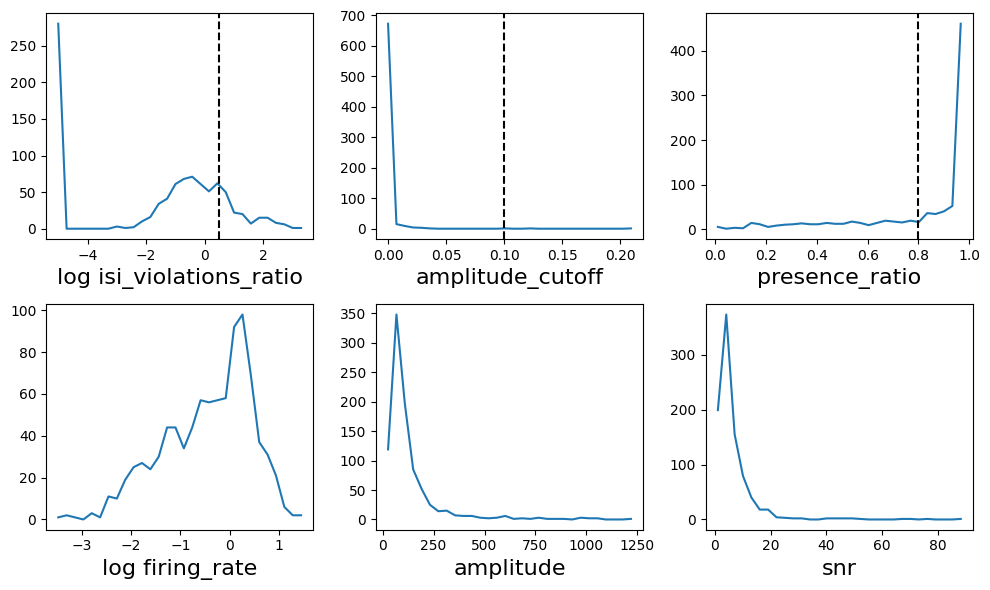

In [11]:
def plot_metric(metric, threshold=None, use_log=False):  
    m = units[metric].dropna()
    if use_log:
        m = np.log10(m+1e-5) # add small offset to avoid log(0)
    h,v = np.histogram(m, bins=30)
    plt.plot(v[:-1],h)
    if use_log:
        plt.xlabel("log "+metric, fontsize=16)
    else:
        plt.xlabel(metric, fontsize=16)
    if threshold:
        plt.axvline(x=threshold, ls='--', color='k')
        
qc_metrics = ['isi_violations_ratio','amplitude_cutoff','presence_ratio','firing_rate','amplitude','snr']
thresholds = [0.5, 0.1, 0.8, None, None, None]
use_log = [True, False, False, True, False, False]
plt.figure(figsize=(10,6))
for i, metric in enumerate(qc_metrics):
    plt.subplot(2,3,i+1)
    plot_metric(metric, thresholds[i], use_log[i])
    plt.tight_layout()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Spike times</h2>

The `spike_times` column contains an array of the times (in seconds) that each unit fired. 

Below, we'll pull the spikes times for a selected single unit and plot as a raster. 
</div>

In [12]:
spike_times = units['spike_times'] 
spike_times.head()

id
0    [422.0354600357091, 603.4513192151259, 696.160...
1    [959.883537661305, 1557.7273983430878, 1591.88...
2    [403.48178941164065, 423.9266776684539, 441.60...
3    [772.7211148520181, 780.3185807966502, 802.445...
4    [380.29834582928805, 380.3205479208549, 380.83...
Name: spike_times, dtype: object

In [13]:
# Select a good quality unit with a predicted cell type == D2 

d2_units = units[(units.default_qc == True) & (units.predicted_cell_type == 'D2')]
d2_units.head()

,spike_times,electrodes,waveform_mean,waveform_sd,unit_name,rp_contamination,shank,half_width,snr,l_ratio,...,internal_red_train_best_mean_jitter,internal_red_train_best_mean_reliability,internal_red_train_best_channel_diff,peak_channel,predicted_cell_type,ccf_ml,ccf_ap,ccf_dv,brain_id,brain_region
id,,,,,,,,,,,,,,,,,,,,,
28,"[380.29071177678986, 380.3205812573287, 380.73...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",993ee8db-7e80-46d4-9b23-a86380e35284,0.538385,,0.000227,7.815937,0.566937,...,NaN,0.012,17.0,33.0,D2,2190.0,5954.0,4002.0,672,CP
51,"[510.31636079570865, 532.0452425288271, 533.49...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",7a65fa30-2a76-4d15-a13a-37fbcd6b3362,0.000000,,0.000203,5.714084,0.010458,...,NaN,0.008,2.0,88.0,D2,2188.0,6015.0,3446.0,997,root
52,"[380.9147286626791, 385.6605262040651, 385.708...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0c76e2ed-c1fd-4ad5-afff-472f9b3df271,0.000000,,0.000253,5.803129,0.238245,...,NaN,0.000,56.0,86.0,D2,2188.0,6015.0,3446.0,997,root
307,"[387.68565883796913, 397.966995404158, 399.838...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",a94a3c53-32f8-4bae-b43a-676d46b59d82,0.184849,,0.000257,5.731665,0.413450,...,NaN,0.044,13.0,33.0,D2,2190.0,5954.0,4002.0,672,CP
320,"[385.4787338515299, 388.82233273383576, 395.85...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",256e920c-f7cd-4296-ae2b-8d90d943d2ca,0.134337,,0.000110,8.060324,0.912741,...,NaN,0.008,2.0,48.0,D2,2233.0,5984.0,3778.0,672,CP


Text(0.5, 0, 'Time (s)')

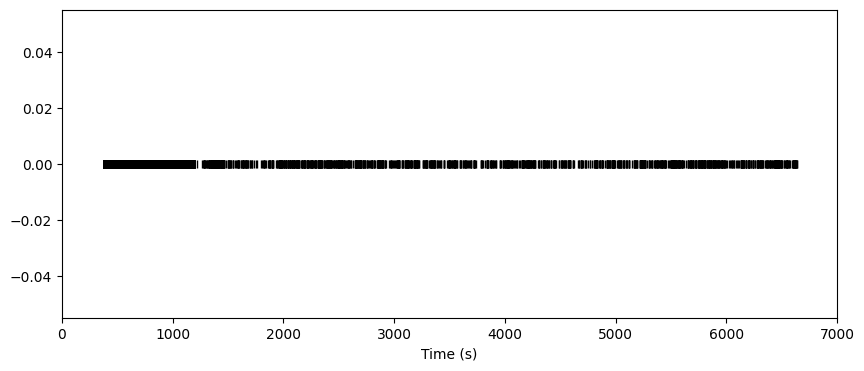

In [14]:
# Plot spike times for selected unit 
unit_idx = d2_units.index[0]

plt.figure(figsize=(10,4))
plt.plot(spike_times[unit_idx], np.repeat(0,len(spike_times[unit_idx])), 'k|')
plt.xlim(0,7000)
plt.xlabel("Time (s)")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>From spike times to a firing rate</h3>

A raster shows individual spikes, but to see how a unit's activity changes over the session it's usually easier to look at a **firing rate** — the number of spikes per unit time. The standard approach is to divide the session into time bins, count the spikes in each, and divide by the bin width. 

The function below converts spike times to firing rate. 

</div>

In [15]:

def calculate_FR(spike_times,bin_size=10):
    """ 
    Calculate spike counts and firing rate from time bins 
    
    Parameters 
    ----------
    spike_times: numpy.ndarray, time points when spikes occurred same unit as bin_size 
    bin_size: float, width of time bin 
    
    Returns 
    --------
    spike_counts: numpy.ndarray, number of spikes in each time bin 
    bin_edges: numpy.ndarray, array of bin edge times 
    firing_rate: numpy.ndarray, firing rate for each bin (spike_counts/bin_size). if bin_size in seconds, firing rate is spikes/sec or Hz. 
    """
    
    # Create time bins that span the full length of spike times 
    t_start = np.floor(spike_times[0])
    t_end = np.ceil(spike_times[-1])
    time_bins = np.arange(t_start, t_end + bin_size, bin_size)
    
    # Count spikes in each time bin 
    spike_counts, bin_edges = np.histogram(spike_times, bins=time_bins)

    # Calculate firing rate
    firing_rate = spike_counts / bin_size
    
    return spike_counts, bin_edges, firing_rate

Text(0, 0.5, 'Firing Rate')

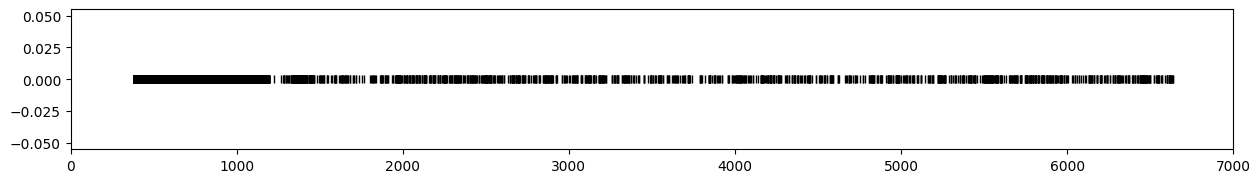

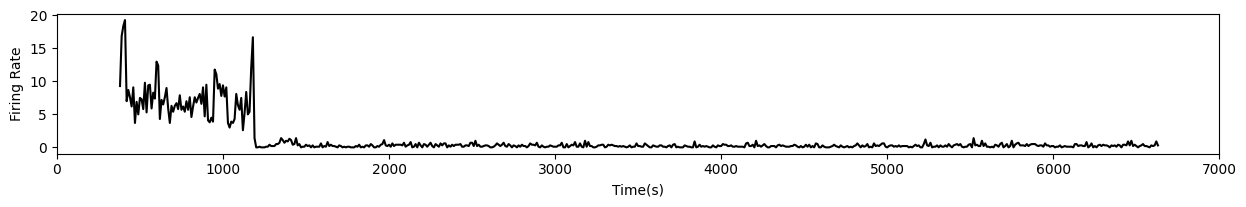

In [16]:
# Get the spike times for the selected unit and plot 

[spike_counts, bin_edges, firing_rate] = calculate_FR(spike_times[unit_idx], bin_size=10) # define 10s time bins

# Plot the firing rate for a single unit across the session
plt.figure(figsize=(15,4))
plt.subplot(2,1,1)
plt.plot(spike_times[unit_idx], np.repeat(0,len(spike_times[unit_idx])), 'k|')
plt.xlim(0,7000)

plt.figure(figsize=(15,4))
plt.subplot(2,1,2)
plt.plot(bin_edges[:-1], firing_rate,color='k') # np.histogram adds 1 extra bin edge, so we'll remove 1 
plt.xlim(0, 7000) 
plt.xlabel('Time(s)')
plt.ylabel('Firing Rate')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Waveforms</h2>

For each unit, the `units` table stores the **mean spike waveform** — the average voltage deflection produced by a spike, recorded across nearby electrodes. Because a Neuropixels probe has many densely spaced sites, a spike appears on several channels at once, and its spatial footprint reflects where the neuron sits relative to the probe. The waveform's shape is also informative: for instance, narrow spikes are often fast-spiking inhibitory neurons while broader spikes tend to be excitatory.

Below we display one unit's mean waveform across electrodes as a heatmap (electrode × time).

</div>

Text(0.5, 0, 'Time')

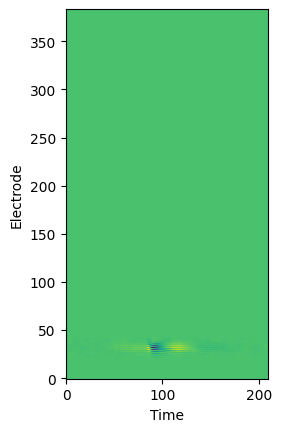

In [17]:
plt.imshow(units.waveform_mean[unit_idx].T, origin='lower')
plt.ylabel("Electrode")
plt.xlabel("Time")

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Recap</h2>

Working with a `units` table comes down to a few repeatable steps: load the table and check its size, understand the columns by family (spike data, quality metrics, waveform features), filter to well-isolated units using quality metrics, and then pull spike times or waveforms for the units you care about. Some specialized datasets have unique columns, such as optotaggin here, but the core structure is the same across ephys datasets. 


</div>